## Homework

Write a generator for electron - positron pairs from the Z boson decay:

$$
Z \rightarrow e^{+} e^{-}
$$

Assume the Z boson is at rest, and its mass is distributed according to the
non relativistic Breit-Wigner (BW) distribution with $m_{Z} = 92.1876$, $\Gamma_{Z} = 2.4952$,
$s = E_{e^{+}} +  E_{e^{-}}$:

$$
p(s) = \frac{1}{\pi \Gamma_{Z}}\frac{\Gamma_{Z}^{2}}{(s-m_{Z})^{2} + \Gamma^{2}}
$$

* generate events with the pair energy in range ```[50,200]```
* assume the decay is isotropic. Is this a correct assumption? - check on some particle physics lecture
* generate at least 500k events. How long it takes? What is the generation efficiency?
* plot histogram of the pair invariant mass with linear and log Y scales. Overlay with probability distribution for invariant mass
* plot histogram of  $cos(\theta)$ of electrons momentum, where $\theta$ is the polar angle. What shape is expected for isotropic distribution?
* plot histogram of transverse electron momentum: $p_{T} = \sqrt{p_{x} + p_{y}} = p \sin(\theta)$. Overlay with probability distribution for transverse momentum.

**Hints:**
* what is the division of energy between $e^{+}$ and $e^{-}$ in the Z boson rest frame?
* the probability distribution for the $p_{T}$ can be obtained from the chain rule:

\begin{equation}
\frac{d\sigma}{dp_{T}} =  \frac{d\sigma}{d\cos(\theta)} \frac{d\cos(\theta)}{dp_{T}}
\end{equation}

* use the nominal Z boson mass while calculating the $\frac{d\sigma}{dp_{T}}$.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
m_Z = 92.1876
gamma_Z = 2.4952

def BreitWigner(s, m, gamma):
    return (1 / (np.pi * gamma)) * (gamma**2) / ((s - m)**2 + gamma**2)

def generateCandidateEnergy(nPoints):
    s_raw = np.random.uniform(50, 200, nPoints)
    prob_accept = BreitWigner(s_raw, m_Z, gamma_Z)
    
    # Accept based on a random threshold (max of BW is 1/(pi*gamma))
    f_max = 1 / (np.pi * gamma_Z)
    u = np.random.uniform(0, f_max, nPoints)
    
    # Return only the values where u <= prob_accept
    return s_raw[u <= prob_accept]

def generateCandidateMomenta(energy):
    n = len(energy)
    E_lep = energy / 2.0
    
    phi = np.random.uniform(0, 2 * np.pi, n)
    cos_theta = np.random.uniform(-1, 1, n)
    sin_theta = np.sqrt(1 - cos_theta**2)
    
    px = E_lep * sin_theta * np.cos(phi)
    py = E_lep * sin_theta * np.sin(phi)
    pz = E_lep * cos_theta
    
    p4_electron = np.column_stack([E_lep, px, py, pz])
    p4_positron = np.column_stack([E_lep, -px, -py, -pz])
    
    return p4_electron, p4_positron

def generateEvents(nPoints):
    energy = generateCandidateEnergy(nPoints)
    data = generateCandidateMomenta(energy)
    return data

def invMass(p4):
    # p4[:, 0] is E, p4[:, 1:4] are px, py, pz
    m2 = p4[:, 0]**2 - np.sum(p4[:, 1:]**2, axis=1)
    return np.sqrt(np.maximum(m2, 0))

Generated 2545198 events for 50000000 tries.
Generation Efficiency: 0.0509


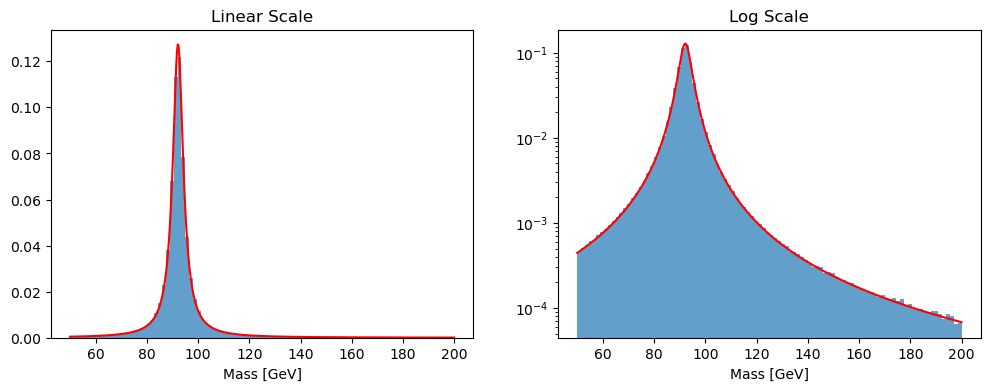

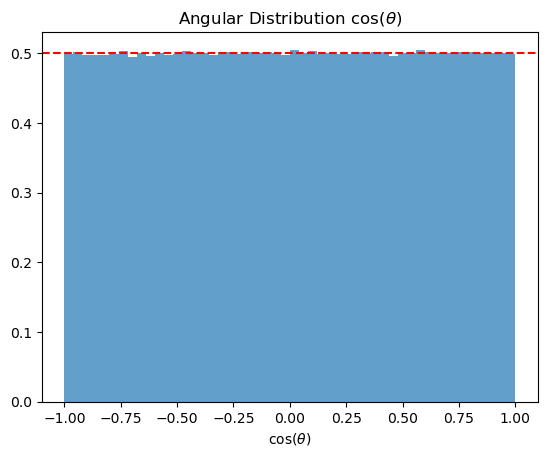

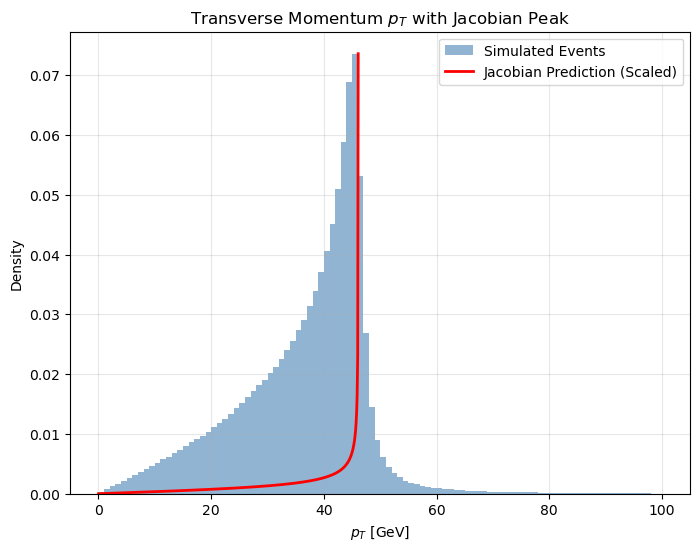

CPU times: user 3.19 s, sys: 268 ms, total: 3.46 s
Wall time: 3.46 s


In [19]:
%%time

minS, maxS = 50, 200
nPoints = int(5E7)

p4_electron, p4_positron = generateEvents(nPoints)
m = invMass(p4_electron + p4_positron)

print(f"Generated {len(m)} events for {nPoints} tries.")
print(f"Generation Efficiency: {len(m)/nPoints:.4f}")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
s_vals = np.linspace(minS, maxS, 500)
bw_curve = BreitWigner(s_vals, m_Z, gamma_Z)

# Linear and Log Mass Histograms
for ax in [ax1, ax2]:
    ax.hist(m, bins=100, range=(minS, maxS), density=True, alpha=0.7, label='Simulated')
    ax.plot(s_vals, bw_curve, 'r-', label='Theoretical BW')
    ax.set_xlabel('Mass [GeV]')
ax2.set_yscale('log')
ax1.set_title("Linear Scale"); ax2.set_title("Log Scale")

# cos(theta) Histogram (Isotropic check)
plt.figure()
cos_theta = p4_electron[:, 3] / p4_electron[:, 0] # pz / E
plt.hist(cos_theta, bins=50, density=True, alpha=0.7)
plt.axhline(0.5, color='r', linestyle='--', label='Flat (Isotropic)')
plt.title(r"Angular Distribution $\cos(\theta)$")
plt.xlabel(r"$\cos(\theta)$")


plt.figure(figsize=(8, 6))

# 1. Plot the simulated data
counts, bins, _ = plt.hist(pT, bins=100, range=(0, 100), density=True, 
                           alpha=0.6, color='steelblue', label='Simulated Events')

# 2. Theoretical Prediction (Jacobian)
E_nom = m_Z / 2.0
# We stop slightly before E_nom to avoid the 1/0 singularity
pt_theory = np.linspace(0.01, E_nom - 0.01, 500)

# The analytical shape: dN/dpT ~ pT / sqrt(E^2 - pT^2)
pdf_raw = pt_theory / (E_nom * np.sqrt(E_nom**2 - pt_theory**2))

# 3. Normalization logic
# The integral of the Jacobian over [0, E] is 1. 
# However, because your simulation has a wide mass range, 
# the "peak" is smeared out. We scale the theory to the histogram height.
scale_factor = np.max(counts) / np.max(pdf_raw) 
plt.plot(pt_theory, pdf_raw * scale_factor, 'r-', lw=2, label='Jacobian Prediction (Scaled)')

plt.title(r'Transverse Momentum $p_T$ with Jacobian Peak')
plt.xlabel('$p_T$ [GeV]')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


